# Week 9 Phase 1.16 — M3 Margin + Repulsion Scale Audit

This executed teaching notebook reads frozen artifacts; the expensive sequential engine lives in the source module.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_16_m3_repulsion_scale_audit'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'conduction': 332,
 'current_head': 'a8eafbbb814f5d5c9fe71a985746d6d1c4cb76eb',
 'exact_branch_base': 'a8eafbbb814f5d5c9fe71a985746d6d1c4cb76eb',
 'historical_M3_margin_q20_AULC': 0.844623161764706,
 'historical_P1_paths': 100,
 'historical_changes': [],
 'initial_design_matches': 100,
 'keyholes': 73,
 'outer_runs': 100,
 'phase14_decision': 'LATE_ACQUISITION_GAIN_ONLY',
 'phase14_sha': '5a7a6c05ae5bf3191b74766156407211ad414360',
 'phase15a_all_selection_matches': True,
 'phase15a_max_probability_difference': 0.0,
 'phase15a_reconstruction_rows': 900,
 'population': 405,
 'repeat_blocks': 20,
 'required_parent_sha': 'a8eafbbb814f5d5c9fe71a985746d6d1c4cb76eb',
 'status': 'PASS'}

## 1. Why revisit repulsion?

Phase 1.14 temporarily narrowed its query path and lost q20 Keyhole recall near B40. The older h=.15 experiment did not test geometry-relative scales.

In [2]:
display(Markdown((OUT/'historical_repulsion_audit.md').read_text())); display(json.loads((OUT/'analysis_specification.json').read_text()))

# Historical repulsion audit

## Week 4 synthetic diversified straddle

- `week4_02_diversified_straddle.py` used `(1-alpha)*normalized_straddle + alpha*normalized_diversity`, with `alpha=0.25`.
- Diversity was minimum Euclidean distance to the queried set in scaled synthetic input coordinates, then min-max normalized over the candidate pool.
- Week 4.03 added a boundary shortlist before a similar additive mixture.
- These were tested on synthetic Branin and Ackley designs; the fixed mixture weight was not a systematic geometry-scale sweep.

## Week 7 / frozen Week 8.5 classifier repulsion

- `week7_phase6_real_data_boundary_active_level_set.py` and Week 8.5 used `normalized_uncertainty * (1-exp(-d_min^2/(2*0.15^2)))`.
- `d_min` used standardized `[P,VX,LS,ST]` geometry; the bandwidth was the fixed raw standardized-space value `0.15`.
- Week 8.5 found slightly larger nearest-query distance but no robust performance improvement for this single configuration.

## Scope of the old conclusion

The defensible historical conclusion is: **one small fixed repulsion configuration did not robustly outperform margin**. It does not establish that repulsion as a principle fails, because neither the raw bandwidth nor a geometry-relative scale response was audited systematically.


{'arms': {'M3_MARGIN': {'c': 0.0,
   'role': 'historical exact Phase 1.14 baseline'},
  'REP_C025': {'c': 0.25, 'role': 'prospective repulsion arm'},
  'REP_C050': {'c': 0.5, 'role': 'prospective repulsion arm'},
  'REP_C100': {'c': 1.0, 'role': 'prospective repulsion arm'},
  'REP_C200': {'c': 2.0, 'role': 'prospective repulsion arm'},
  'REP_C400': {'c': 4.0, 'role': 'prospective repulsion arm'}},
 'c_grid': [0.25, 0.5, 1.0, 2.0, 4.0],
 'decision_categories': ['REPULSION_GAIN_ROBUST',
  'REPULSION_MECHANISM_ONLY',
  'REPULSION_SCALE_SENSITIVE',
  'REPULSION_NO_GAIN',
  'REPULSION_HARMS_BOUNDARY_LEARNING',
  'REPULSION_NUMERICALLY_UNRELIABLE'],
 'inference': {'bootstrap_draws': 10000,
  'multiplicity': 'Holm across five overall q20 contrasts',
  'unit': '20 repeat blocks with five folds retained'},
 'model': {'kernel': 'ARD Matern-3/2',
  'length_bounds': [0.01, 100.0],
  'log_h_in_residual': False,
  'name': 'M3',
  'physics_mean': 'training-fitted log(h), frozen before discrepancy f

## 2. Predeclared scale response

`c=0` is plain M3 margin. Every positive c multiplies the same margin score by a smooth geometry-relative repulsion factor.

,arm,c,q20_AULC,overall_q20_delta,overall_ci_lower,overall_ci_upper,early_q20_delta,late_q20_delta,B40_keyhole_recall_delta,B40_query_spread,B40_query_spread_delta,B84_median_first_hit,B84_median_first_hit_delta
0,M3_MARGIN,0.00,0.844623,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.257871,0.000000,25.5,0.0
1,REP_C025,0.25,0.846144,0.001521,-0.000744,0.003676,0.002218,0.001011,-0.017889,2.215412,-0.042459,27.0,1.5
2,REP_C050,0.50,0.846094,0.001471,-0.001255,0.004049,0.003395,0.000226,-0.016163,2.272938,0.015067,25.5,0.0
3,REP_C100,1.00,0.847169,0.002546,-0.000648,0.005597,0.004890,0.001003,-0.013837,2.329993,0.072122,26.0,0.5
4,REP_C200,2.00,0.846861,0.002238,-0.001673,0.005786,0.004975,0.000445,-0.011135,2.355959,0.098088,24.5,-1.0
5,REP_C400,4.00,0.847321,0.002698,-0.000892,0.005970,0.006103,0.000505,-0.003230,2.358943,0.101071,24.0,-1.5


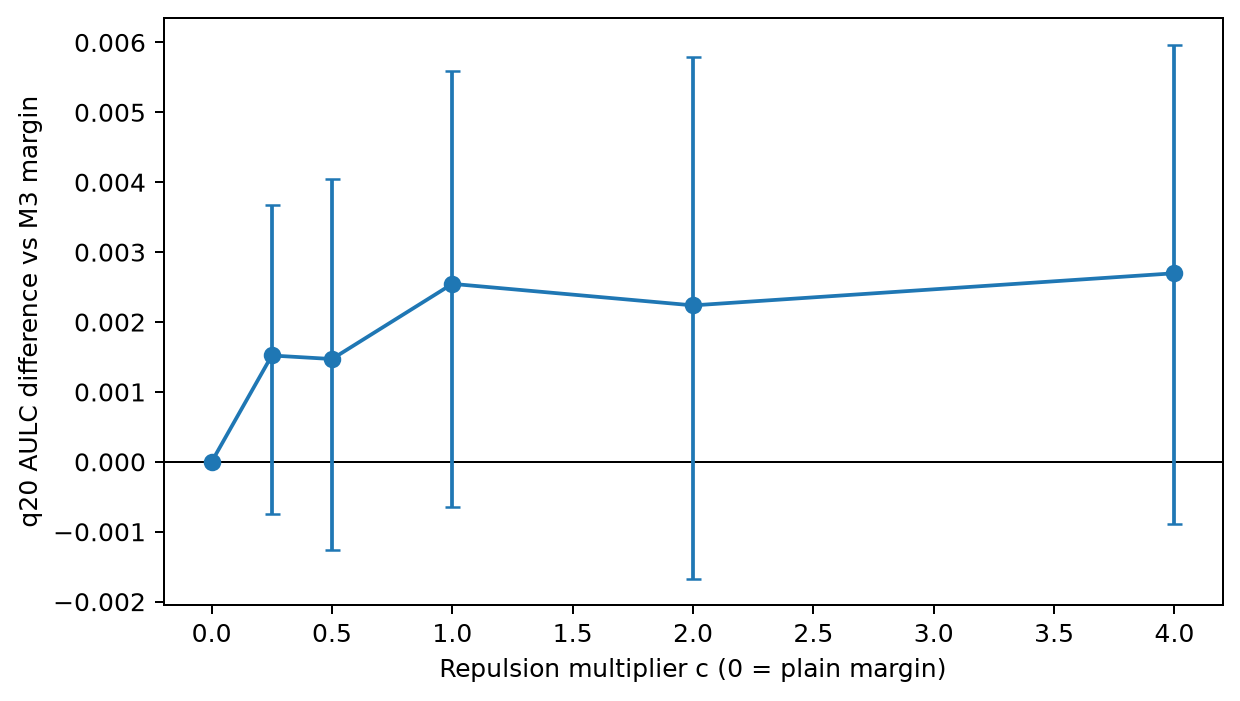

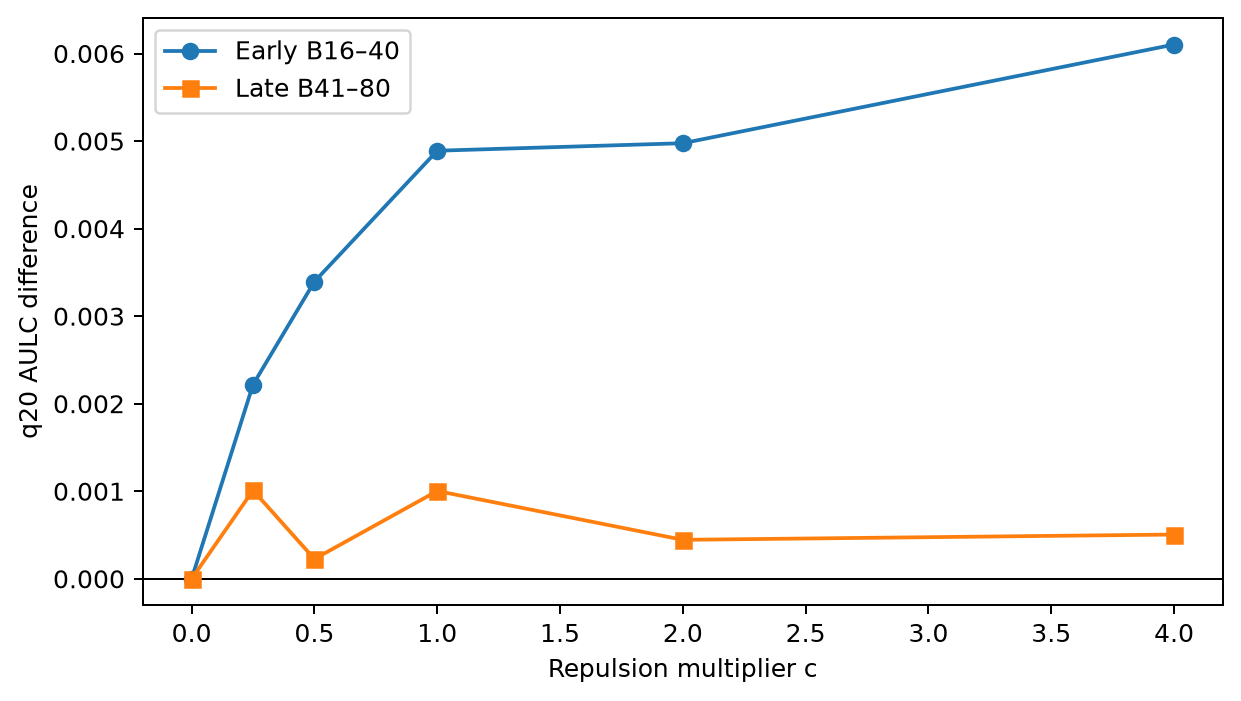

In [3]:
display(pd.read_csv(OUT/'repulsion_scale_response.csv')); display(Image(filename=str(OUT/'figures'/'01_q20_aulc_scale_response.png'))); display(Image(filename=str(OUT/'figures'/'02_early_late_scale_response.png')))

## 3. Did repulsion fix the B40 failure mode?

,arm,c,subset,budget,metric,mean,median,n_outer_runs
18,M3_MARGIN,0.00,B1_q20,40,accuracy,0.846471,0.882353,100
19,M3_MARGIN,0.00,B1_q20,40,balanced_accuracy,0.827068,0.833333,100
20,M3_MARGIN,0.00,B1_q20,40,keyhole_recall,0.748738,0.750000,100
21,M3_MARGIN,0.00,B1_q20,40,conduction_recall,0.905398,0.909091,100
22,M3_MARGIN,0.00,B1_q20,40,false_negative,1.620000,2.000000,100
23,M3_MARGIN,0.00,B1_q20,40,false_positive,0.990000,1.000000,100
54,REP_C025,0.25,B1_q20,40,accuracy,0.850588,0.882353,100
55,REP_C025,0.25,B1_q20,40,balanced_accuracy,0.825744,0.833333,100
56,REP_C025,0.25,B1_q20,40,keyhole_recall,0.730849,0.750000,100
57,REP_C025,0.25,B1_q20,40,conduction_recall,0.920638,0.916667,100


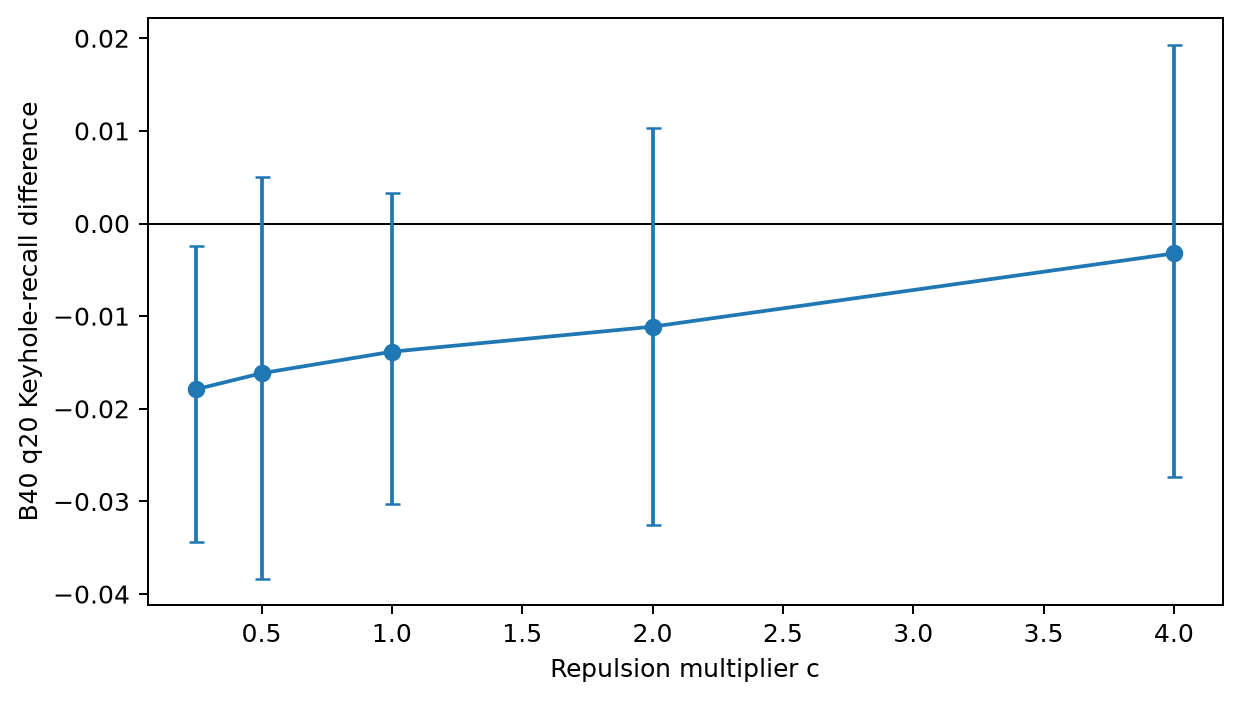

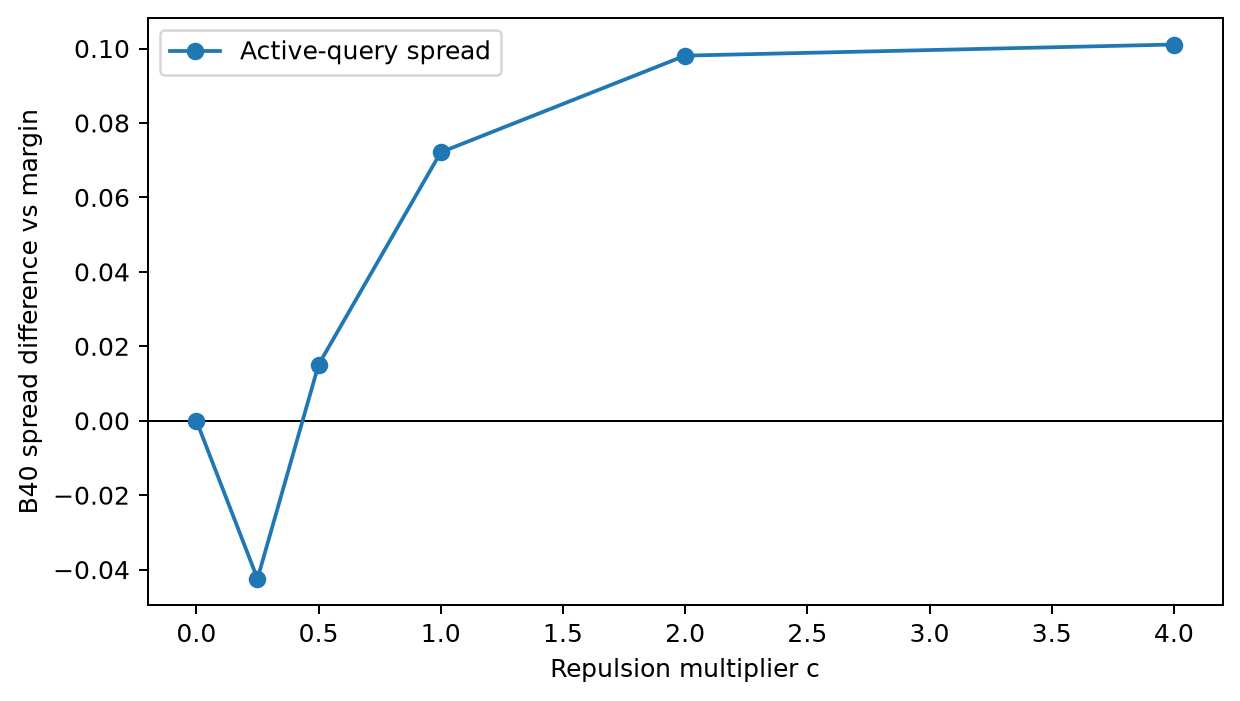

In [4]:
display(pd.read_csv(OUT/'q20_checkpoint_metrics.csv').query("budget==40")); display(Image(filename=str(OUT/'figures'/'03_b40_keyhole_recall.png'))); display(Image(filename=str(OUT/'figures'/'04_diversity_scale_response.png')))

## 4. Sample efficiency and q30 robustness

,arm,c,threshold,reach_rate,median_first_hit_budget,paired_repeats_both_reached,mean_first_hit_difference_vs_margin,ci_lower,ci_upper,noncrossings_not_imputed
0,M3_MARGIN,0.00,0.80,1.0,17.0,20,0.00,0.00000,0.00,True
1,REP_C025,0.25,0.80,1.0,17.0,20,-0.30,-0.85000,0.00,True
2,REP_C050,0.50,0.80,1.0,17.0,20,-0.10,-0.25000,0.00,True
3,REP_C100,1.00,0.80,1.0,17.0,20,-0.55,-1.45000,0.00,True
4,REP_C200,2.00,0.80,1.0,17.0,20,-0.55,-1.45000,0.00,True
5,REP_C400,4.00,0.80,1.0,17.0,20,-0.55,-1.45000,0.00,True
6,M3_MARGIN,0.00,0.82,1.0,17.5,20,0.00,0.00000,0.00,True
7,REP_C025,0.25,0.82,1.0,17.5,20,0.65,0.15000,1.30,True
8,REP_C050,0.50,0.82,1.0,17.5,20,0.65,-0.40000,1.85,True
9,REP_C100,1.00,0.82,1.0,18.0,20,0.85,-0.40000,2.45,True


,arm,c,subset,region,mean_AULC,delta_vs_M3_MARGIN,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws
0,M3_MARGIN,0.00,B1_q30,OVERALL_B16_80,0.887434,0.000000,0.000000,0.000000,0,20,0,10000
1,REP_C025,0.25,B1_q30,OVERALL_B16_80,0.889841,0.002406,0.000616,0.004084,14,0,6,10000
2,REP_C050,0.50,B1_q30,OVERALL_B16_80,0.889766,0.002331,0.000278,0.004256,15,0,5,10000
3,REP_C100,1.00,B1_q30,OVERALL_B16_80,0.890666,0.003231,0.000875,0.005363,17,0,3,10000
4,REP_C200,2.00,B1_q30,OVERALL_B16_80,0.890572,0.003137,0.000447,0.005666,15,1,4,10000
5,REP_C400,4.00,B1_q30,OVERALL_B16_80,0.890791,0.003356,0.000747,0.005728,15,1,4,10000


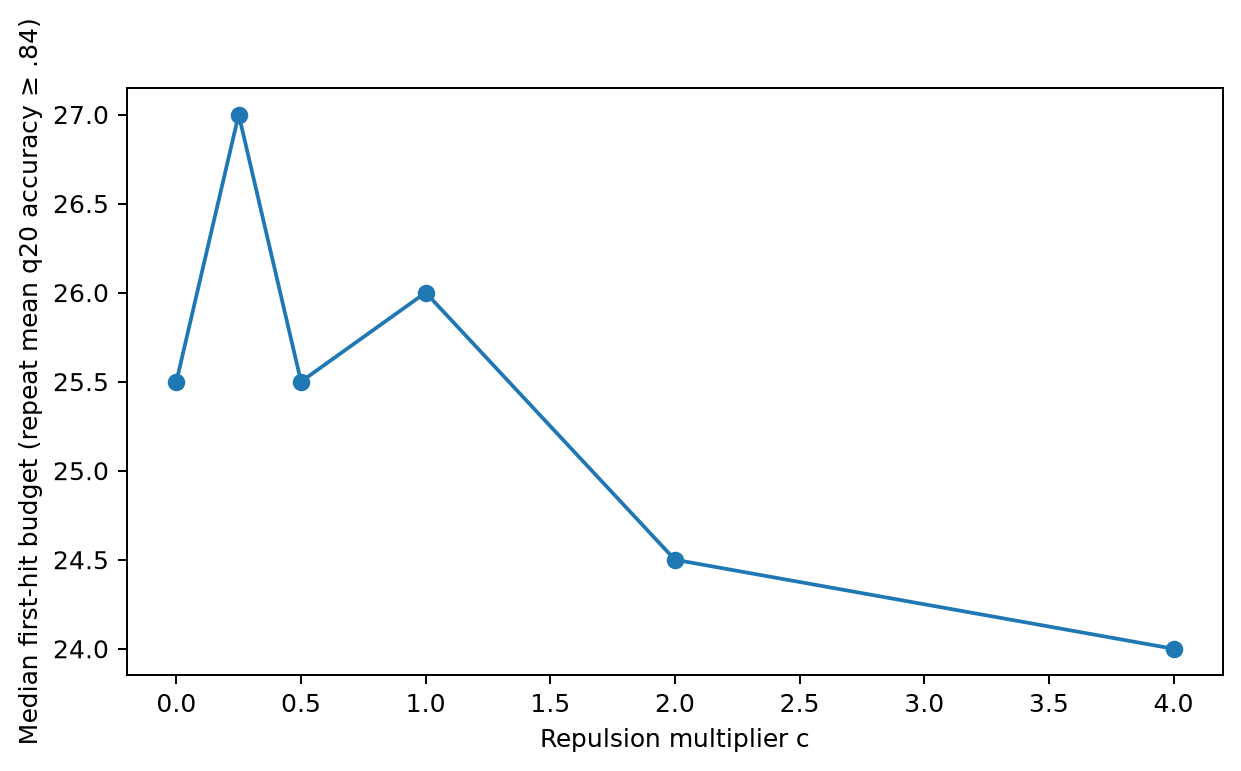

In [5]:
display(pd.read_csv(OUT/'sample_efficiency_thresholds.csv')); display(pd.read_csv(OUT/'q30_robustness.csv')); display(Image(filename=str(OUT/'figures'/'05_sample_efficiency_scale_response.png')))

## 5. Paths and numerical behavior

,arm,c,budget,first_divergence_budget_mean,same_step_fraction_active,shared_point_count,jaccard
1,M3_MARGIN,0.00,40,NaN,1.000000,40.00,1.000000
5,REP_C025,0.25,40,21.51,0.264167,35.03,0.786126
9,REP_C050,0.50,40,18.62,0.137500,33.14,0.714817
13,REP_C100,1.00,40,17.80,0.081250,31.92,0.670961
17,REP_C200,2.00,40,17.60,0.068750,31.60,0.660578
21,REP_C400,4.00,40,17.59,0.067500,31.50,0.657356


,arm,c,region,fits,optimizer_convergence_rate,mean_residual_sd,residual_sd_upper_hit_rate,any_length_lower_hit_rate,any_length_upper_hit_rate,median_anisotropy_ratio
0,M3_MARGIN,0.00,EARLY_B16_40,2500,0.98640,0.760409,0.62160,0.02280,0.76720,230.088232
1,M3_MARGIN,0.00,LATE_B41_80,4000,0.93475,0.962986,0.78150,0.00175,0.81000,198.132712
2,REP_C025,0.25,EARLY_B16_40,2500,0.98600,0.744929,0.56800,0.01360,0.76920,224.496095
3,REP_C025,0.25,LATE_B41_80,4000,0.92000,0.969840,0.79225,0.00125,0.81400,185.615536
4,REP_C050,0.50,EARLY_B16_40,2500,0.98080,0.763645,0.59440,0.02440,0.77720,214.642929
5,REP_C050,0.50,LATE_B41_80,4000,0.91975,0.973818,0.84475,0.00350,0.82300,184.167557
6,REP_C100,1.00,EARLY_B16_40,2500,0.98160,0.763163,0.59520,0.01840,0.76920,206.661919
7,REP_C100,1.00,LATE_B41_80,4000,0.92500,0.969322,0.85950,0.00700,0.84725,188.273961
8,REP_C200,2.00,EARLY_B16_40,2500,0.98120,0.758255,0.58040,0.02680,0.76960,206.829330
9,REP_C200,2.00,LATE_B41_80,4000,0.92550,0.969829,0.85875,0.00750,0.84300,189.039508


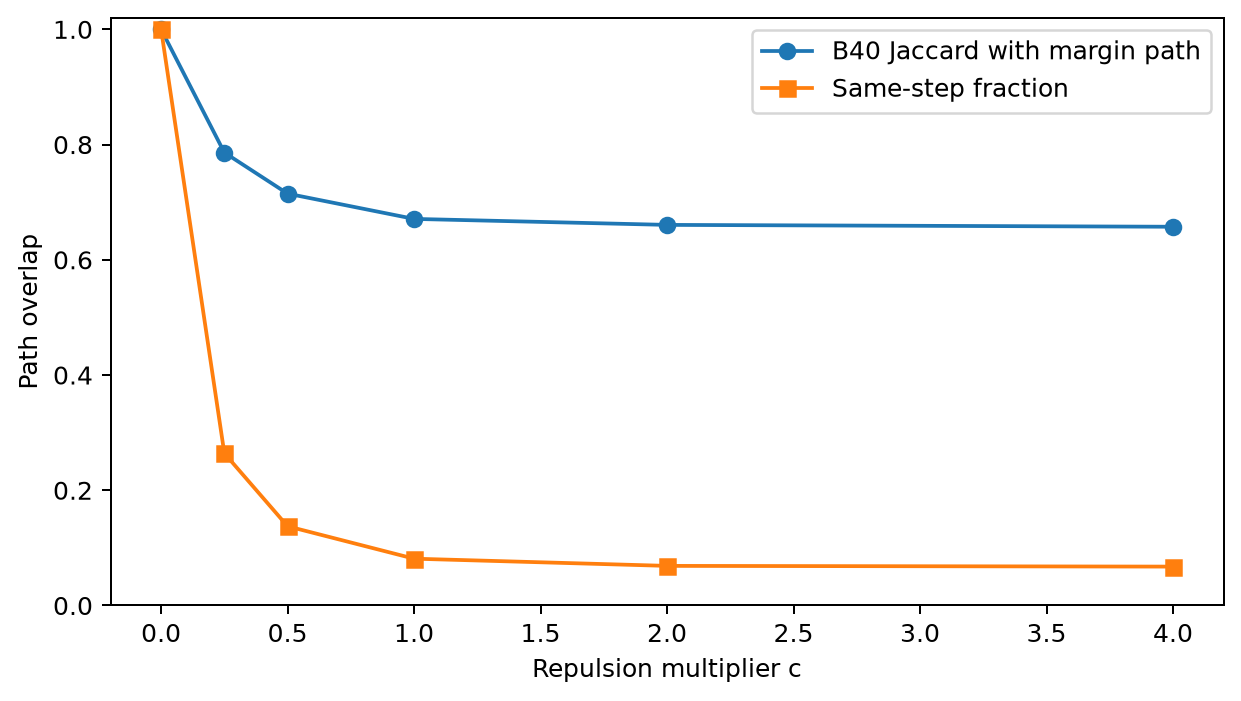

In [6]:
display(pd.read_csv(OUT/'path_overlap_summary.csv').query("budget==40")); display(pd.read_csv(OUT/'fit_diagnostics_summary.csv')); display(Image(filename=str(OUT/'figures'/'06_path_overlap.png')))

## 6. Multiplicity and safe decision

In [7]:
display(pd.read_csv(OUT/'multiplicity_summary.csv')); display(Markdown((OUT/'SUPERVISOR_PHASE1_16_ONE_PAGE.md').read_text()))

,arm,c,delta_vs_M3_MARGIN,ci_lower,ci_upper,positive_repeat_blocks,negative_repeat_blocks,raw_sign_test_p,holm_adjusted_p,holm_reject_0_05
0,REP_C025,0.25,0.001521,-0.000744,0.003676,14,6,0.115318,0.461273,False
1,REP_C050,0.50,0.001471,-0.001255,0.004049,12,7,0.359283,0.526352,False
2,REP_C100,1.00,0.002546,-0.000648,0.005597,13,7,0.263176,0.526352,False
3,REP_C200,2.00,0.002238,-0.001673,0.005786,14,6,0.115318,0.461273,False
4,REP_C400,4.00,0.002698,-0.000892,0.005970,15,5,0.041389,0.206947,False


# Supervisor Phase 1.16 one-page

**Decision:** REPULSION_MECHANISM_ONLY

- Historical h=.15 repulsion was one fixed configuration; Phase 1.16 tested geometry-relative c=.25,.5,1,2,4 without held-out tuning.
- M3-margin baseline q20 AULC: 0.844623.
- Best numerical q20 arm: c=4, difference +0.0027 [-0.0009, +0.0060]; every primary CI includes zero.
- Early q20 AULC improves most for c=1 and c=4, but late gains are small and unresolved.
- B40 spread is larger for câ‰¥.5 (maximum Î” +0.101), so spatial narrowing is genuinely mitigated.
- B40 q20 Keyhole recall does not improve at any scale; c=.25 is significantly worse (-0.0179).
- q30 AULC improves slightly at all five scales, but this is secondary to the unresolved q20 endpoint.
- .84 first-hit differences all include zero; there is no supported query-saving result.
- B80 full81 performance is essentially unchanged; no global harm signal.
- No primary q20 contrast survives Holm adjustment (minimum adjusted p=0.207).
- Safest conclusion: repulsion fixes geometry, not the Keyhole-recall/sample-efficiency problem. Close broad repulsion tuning rather than searching more scales.
